# PneumoFusionNet — Chest X-Ray Pneumonia Detection
### ResNet50 (1-ch Grayscale) + GCSA + DSC
**Dataset:** Chest X-Ray Images (NORMAL vs PNEUMONIA)

In [1]:
import os, random, copy, warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm_mpl
import seaborn as sns
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader, WeightedRandomSampler
import torchvision
from torchvision import datasets, transforms, models
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, accuracy_score
)
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)
if DEVICE.type == 'cuda': print('GPU:', torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [2]:
DATA_DIR    = '/kaggle/input/chest-xray-pneumonia/chest_xray'
if not os.path.exists(DATA_DIR):
    for root, dirs, files in os.walk('/kaggle/input'):
        if 'train' in dirs and 'test' in dirs:
            DATA_DIR = root; print('Found:', DATA_DIR); break
SAVE_DIR    = '/kaggle/working'
MODEL_PATH  = os.path.join(SAVE_DIR, 'best_pneumofusion_model.pth')
IMG_SIZE=224; BATCH_SIZE=32; NUM_EPOCHS=25; LR=1e-4; WEIGHT_DECAY=1e-5; NUM_CLASSES=2
CLASSES=['NORMAL','PNEUMONIA']; MEAN=[0.449]; STD=[0.226]
print('Data dir:', DATA_DIR)
for s in ['train','val','test']:
    for c in CLASSES:
        p=os.path.join(DATA_DIR,s,c)
        n=len(os.listdir(p)) if os.path.exists(p) else 'MISSING'
        print(f'  {s}/{c}: {n}')

Found: /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray
Data dir: /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray
  train/NORMAL: 1341
  train/PNEUMONIA: 3875
  val/NORMAL: 8
  val/PNEUMONIA: 8
  test/NORMAL: 234
  test/PNEUMONIA: 390


## Transforms — Grayscale (1 Channel)

In [3]:
tfms = {
    'train': transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((256, 256)),
        transforms.RandomCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.3, contrast=0.3),
        transforms.ToTensor(),
        transforms.Normalize(mean=MEAN, std=STD)
    ]),
    'val': transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=MEAN, std=STD)
    ]),
    'test': transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=MEAN, std=STD)
    ]),
}
print('Grayscale transforms ready.')

Grayscale transforms ready.


In [4]:
image_datasets = {
    s: datasets.ImageFolder(os.path.join(DATA_DIR, s), tfms[s])
    for s in ['train', 'val', 'test']
}
train_labels   = [s[1] for s in image_datasets['train'].samples]
class_counts   = np.bincount(train_labels)
sample_weights = [1.0 / class_counts[l] for l in train_labels]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)
dataloaders = {
    'train': DataLoader(image_datasets['train'], batch_size=BATCH_SIZE,
                        sampler=sampler, num_workers=2, pin_memory=True),
    'val':   DataLoader(image_datasets['val'],   batch_size=BATCH_SIZE,
                        shuffle=False, num_workers=2, pin_memory=True),
    'test':  DataLoader(image_datasets['test'],  batch_size=BATCH_SIZE,
                        shuffle=False, num_workers=2, pin_memory=True),
}
dataset_sizes = {s: len(image_datasets[s]) for s in ['train','val','test']}
print('Dataset sizes:', dataset_sizes)
print('Class index  :', image_datasets['train'].class_to_idx)
# Verify 1-channel input
sample_batch, _ = next(iter(dataloaders['train']))
print('Batch shape (B,C,H,W):', sample_batch.shape)  # should be [32, 1, 224, 224]

Dataset sizes: {'train': 5216, 'val': 16, 'test': 624}
Class index  : {'NORMAL': 0, 'PNEUMONIA': 1}
Batch shape (B,C,H,W): torch.Size([32, 1, 224, 224])


## Visualise Sample Images

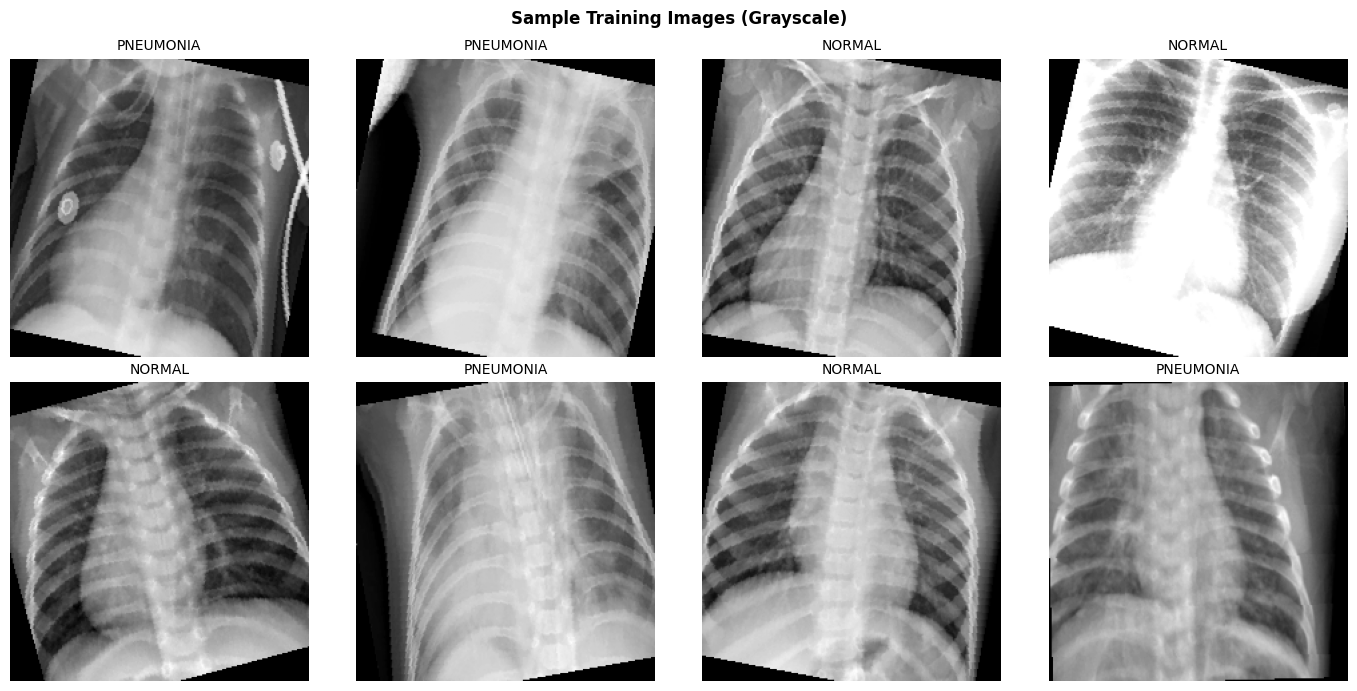

In [5]:
inputs, cls_idx = next(iter(dataloaders['train']))
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i, ax in enumerate(axes.flatten()):
    img = inputs[i].squeeze().numpy()
    img = img * STD[0] + MEAN[0]
    img = np.clip(img, 0, 1)
    ax.imshow(img, cmap='gray')
    ax.set_title(CLASSES[cls_idx[i].item()], fontsize=10)
    ax.axis('off')
plt.suptitle('Sample Training Images (Grayscale)', fontweight='bold')
plt.tight_layout(); plt.show()

## Model: PneumoFusionNet with 1-Channel ResNet50 + GCSA + DSC

In [6]:
class ChannelAttention(nn.Module):
    def __init__(self, ch, r=16):
        super().__init__()
        self.avg = nn.AdaptiveAvgPool2d(1)
        self.mx  = nn.AdaptiveMaxPool2d(1)
        self.fc  = nn.Sequential(
            nn.Linear(ch, ch // r, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(ch // r, ch, bias=False)
        )
        self.sig = nn.Sigmoid()
    def forward(self, x):
        b, c, _, _ = x.size()
        a = self.fc(self.avg(x).view(b, c))
        m = self.fc(self.mx(x).view(b, c))
        return self.sig((a + m).view(b, c, 1, 1)) * x

class SpatialAttention(nn.Module):
    def __init__(self, k=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, k, padding=k//2, bias=False)
        self.sig  = nn.Sigmoid()
    def forward(self, x):
        a = torch.mean(x, dim=1, keepdim=True)
        m, _ = torch.max(x, dim=1, keepdim=True)
        return self.sig(self.conv(torch.cat([a, m], dim=1))) * x

class GCSA(nn.Module):
    def __init__(self, ch, r=16):
        super().__init__()
        self.ca = ChannelAttention(ch, r)
        self.sa = SpatialAttention()
    def forward(self, x): return self.sa(self.ca(x))

class DSC(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.dw  = nn.Conv2d(in_ch, in_ch, 3, padding=1, groups=in_ch, bias=False)
        self.pw  = nn.Conv2d(in_ch, out_ch, 1, bias=False)
        self.bn  = nn.BatchNorm2d(out_ch)
        self.act = nn.ReLU(inplace=True)
    def forward(self, x): return self.act(self.bn(self.pw(self.dw(x))))

class PneumoFusionNet(nn.Module):
    def __init__(self, num_classes=2, pretrained=True):
        super().__init__()
        bb = models.resnet50(pretrained=pretrained)
        # ── Modify first conv: 3ch → 1ch grayscale ──────────────────
        old_conv = bb.conv1  # shape: (64, 3, 7, 7)
        new_conv = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        with torch.no_grad():
            # Average RGB weights → single grayscale channel
            new_conv.weight = nn.Parameter(
                old_conv.weight.mean(dim=1, keepdim=True)
            )
        bb.conv1 = new_conv
        # ─────────────────────────────────────────────────────────────
        self.features   = nn.Sequential(*list(bb.children())[:-2])
        self.gcsa       = GCSA(2048)
        self.dsc        = DSC(2048, 512)
        self.pool       = nn.AdaptiveAvgPool2d(1)
        self.dropout    = nn.Dropout(0.4)
        self.classifier = nn.Linear(512, num_classes)
    def forward(self, x):
        x = self.features(x)
        x = self.gcsa(x)
        x = self.dsc(x)
        x = self.pool(x).flatten(1)
        return self.classifier(self.dropout(x))

model = PneumoFusionNet(num_classes=NUM_CLASSES, pretrained=True).to(DEVICE)
total = sum(p.numel() for p in model.parameters())
print(f'Total parameters: {total:,}')
# Quick shape test
with torch.no_grad():
    dummy = torch.zeros(1, 1, 224, 224).to(DEVICE)
    out   = model(dummy)
    print(f'Input shape : (1, 1, 224, 224)')
    print(f'Output shape: {tuple(out.shape)}')

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 210MB/s]


Total parameters: 25,095,204
Input shape : (1, 1, 224, 224)
Output shape: (1, 2)


In [7]:
cw = torch.tensor(1.0 / class_counts, dtype=torch.float).to(DEVICE)
cw = cw / cw.sum()
criterion = nn.CrossEntropyLoss(weight=cw)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)
print('Criterion:', criterion)
print('Optimizer:', optimizer.__class__.__name__)

Criterion: CrossEntropyLoss()
Optimizer: AdamW


## Train from Scratch

In [8]:
history  = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}
best_wts = copy.deepcopy(model.state_dict())
best_acc = 0.0
for epoch in range(NUM_EPOCHS):
    print(f'\nEpoch {epoch+1}/{NUM_EPOCHS}  lr={scheduler.get_last_lr()[0]:.2e}')
    print('-' * 55)
    for phase in ['train', 'val']:
        model.train() if phase == 'train' else model.eval()
        loss_sum = 0.0; correct = 0
        for X, y in dataloaders[phase]:
            X, y = X.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            with torch.set_grad_enabled(phase == 'train'):
                out  = model(X)
                loss = criterion(out, y)
                if phase == 'train': loss.backward(); optimizer.step()
            loss_sum += loss.item() * X.size(0)
            correct  += (out.argmax(1) == y).sum().item()
        ep_loss = loss_sum / dataset_sizes[phase]
        ep_acc  = correct  / dataset_sizes[phase]
        history[f'{phase}_loss'].append(ep_loss)
        history[f'{phase}_acc'].append(ep_acc)
        print(f'  {phase:5s} | loss: {ep_loss:.4f}  acc: {ep_acc:.4f}')
        if phase == 'val' and ep_acc > best_acc:
            best_acc = ep_acc
            best_wts = copy.deepcopy(model.state_dict())
            torch.save(best_wts, MODEL_PATH)
            print(f'  *** Best model saved (val_acc={best_acc:.4f})')
    scheduler.step()
print(f'\nTraining complete! Best val acc: {best_acc:.4f}')
model.load_state_dict(best_wts)


Epoch 1/25  lr=1.00e-04
-------------------------------------------------------
  train | loss: 0.1182  acc: 0.9346
  val   | loss: 0.2333  acc: 0.8750
  *** Best model saved (val_acc=0.8750)

Epoch 2/25  lr=9.96e-05
-------------------------------------------------------
  train | loss: 0.0625  acc: 0.9697
  val   | loss: 0.0346  acc: 1.0000
  *** Best model saved (val_acc=1.0000)

Epoch 3/25  lr=9.84e-05
-------------------------------------------------------
  train | loss: 0.0620  acc: 0.9705
  val   | loss: 0.1301  acc: 0.9375

Epoch 4/25  lr=9.65e-05
-------------------------------------------------------
  train | loss: 0.0490  acc: 0.9762
  val   | loss: 0.1184  acc: 0.8750

Epoch 5/25  lr=9.39e-05
-------------------------------------------------------
  train | loss: 0.0383  acc: 0.9822
  val   | loss: 0.0833  acc: 1.0000

Epoch 6/25  lr=9.05e-05
-------------------------------------------------------
  train | loss: 0.0314  acc: 0.9870
  val   | loss: 0.0775  acc: 0.9375

E

<All keys matched successfully>

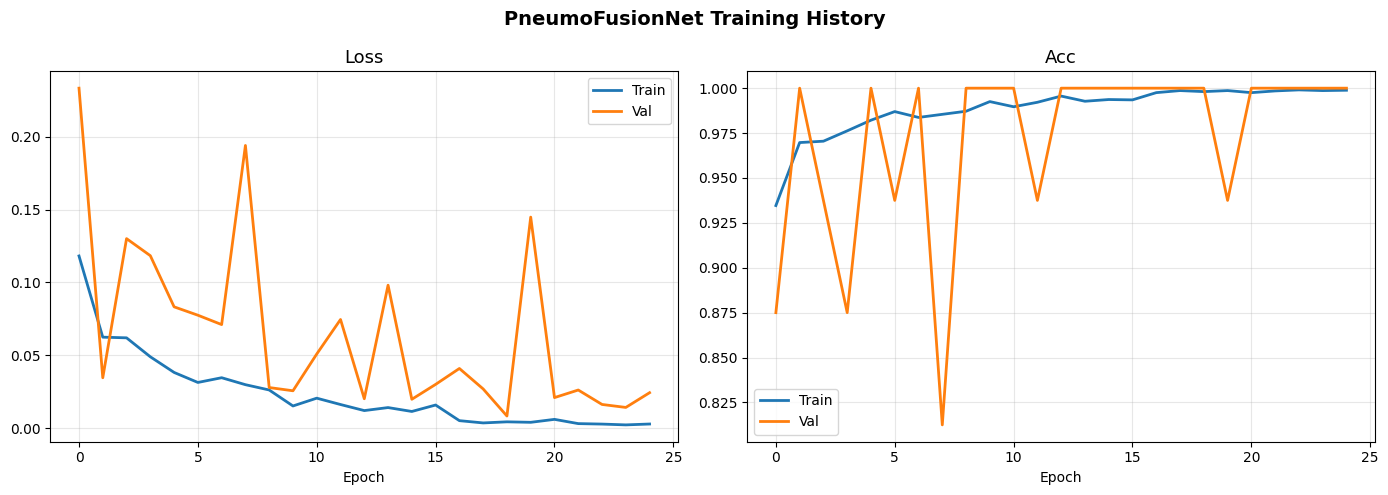

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, metric in zip(axes, ['loss', 'acc']):
    ax.plot(history[f'train_{metric}'], label='Train', linewidth=2)
    ax.plot(history[f'val_{metric}'],   label='Val',   linewidth=2)
    ax.set_title(metric.capitalize(), fontsize=13)
    ax.set_xlabel('Epoch'); ax.legend(); ax.grid(True, alpha=0.3)
plt.suptitle('PneumoFusionNet Training History', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## Final Evaluation on Test Set

  Accuracy : 92.47%
  ROC-AUC  : 0.9776
              precision    recall  f1-score   support

      NORMAL       0.91      0.89      0.90       234
   PNEUMONIA       0.93      0.95      0.94       390

    accuracy                           0.92       624
   macro avg       0.92      0.92      0.92       624
weighted avg       0.92      0.92      0.92       624



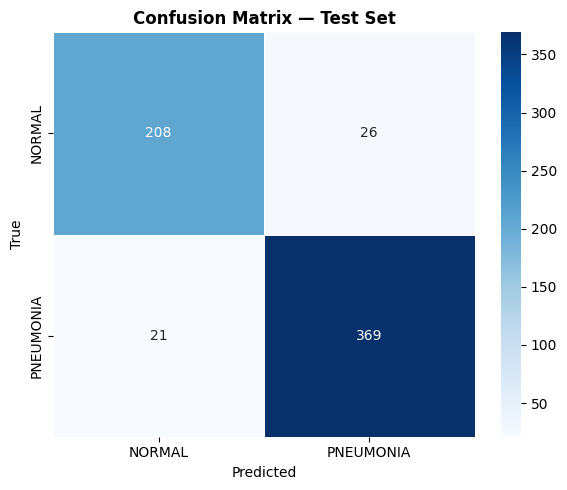

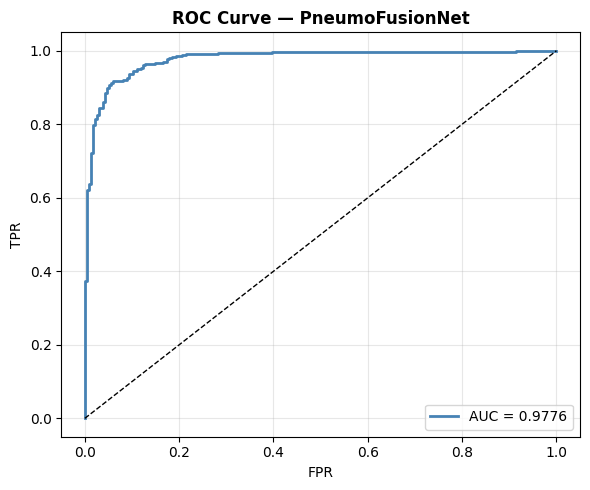

In [10]:
model.eval()
all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for X, y in dataloaders['test']:
        X = X.to(DEVICE)
        out   = model(X)
        probs = F.softmax(out, dim=1)[:, 1].cpu().numpy()
        preds = out.argmax(1).cpu().numpy()
        all_preds.extend(preds); all_labels.extend(y.numpy()); all_probs.extend(probs)
all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)
acc = accuracy_score(all_labels, all_preds)
auc = roc_auc_score(all_labels, all_probs)
print('=' * 55)
print(f'  Accuracy : {acc * 100:.2f}%')
print(f'  ROC-AUC  : {auc:.4f}')
print(classification_report(all_labels, all_preds, target_names=CLASSES))
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES, linewidths=0.5)
plt.title('Confusion Matrix — Test Set', fontweight='bold')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.tight_layout(); plt.show()
fpr, tpr, _ = roc_curve(all_labels, all_probs)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, lw=2, color='steelblue', label=f'AUC = {auc:.4f}')
plt.plot([0,1],[0,1],'k--', lw=1)
plt.xlabel('FPR'); plt.ylabel('TPR')
plt.title('ROC Curve — PneumoFusionNet', fontweight='bold')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## GradCAM Visualizations

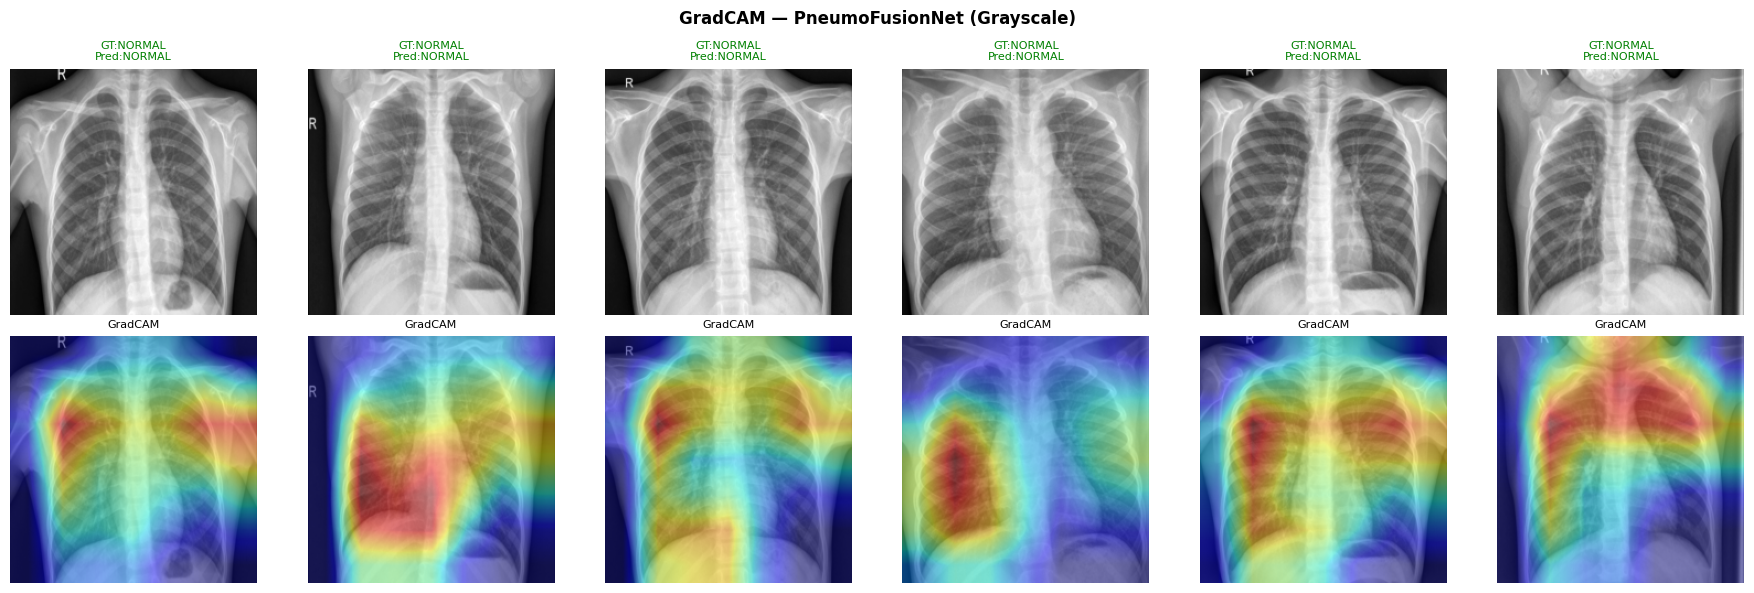

In [18]:
class GradCAM:
    def __init__(self, model, layer):
        self.model  = model
        self.grads  = None
        self.acts   = None
        self.handles = []
        self.handles.append(layer.register_forward_hook(self._save_acts))
        self.handles.append(layer.register_backward_hook(self._save_grads))

    def _save_acts(self, module, input, output):
        self.acts = output.detach()

    def _save_grads(self, module, grad_in, grad_out):
        self.grads = grad_out[0].detach()

    def remove_hooks(self):
        for h in self.handles:
            h.remove()

    def generate(self, x, idx=None):
        out = self.model(x)
        if idx is None: idx = out.argmax(1).item()
        self.model.zero_grad()
        out[0, idx].backward()
        w   = self.grads.mean(dim=[2,3], keepdim=True)
        cam = F.relu((w * self.acts).sum(dim=1, keepdim=True))
        cam = F.interpolate(cam, (224,224), mode='bilinear', align_corners=False)
        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, idx


def show_gradcam(model, loader, n=6):
    gc = GradCAM(model, model.features[-1][-1].conv3)
    X, y = next(iter(loader))
    X, y = X.to(DEVICE), y
    fig, axes = plt.subplots(2, n, figsize=(18, 6))
    for i in range(n):
        cam, pi = gc.generate(X[i:i+1])
        # Denormalise grayscale image
        orig = X[i].squeeze().cpu().numpy()
        orig = orig * STD[0] + MEAN[0]
        orig = np.clip(orig, 0, 1)
        axes[0,i].imshow(orig, cmap='gray'); axes[0,i].axis('off')
        col = 'green' if pi == y[i].item() else 'red'
        axes[0,i].set_title(f'GT:{CLASSES[y[i]]}\nPred:{CLASSES[pi]}', fontsize=8, color=col)
        heat = cm_mpl.jet(cam)[:,:,:3]
        orig_rgb = np.stack([orig]*3, axis=-1)
        axes[1,i].imshow(np.clip(0.55*orig_rgb + 0.45*heat, 0, 1))
        axes[1,i].axis('off'); axes[1,i].set_title('GradCAM', fontsize=8)
    plt.suptitle('GradCAM — PneumoFusionNet (Grayscale)', fontweight='bold')
    plt.tight_layout(); plt.show()

show_gradcam(model, dataloaders['test'])

## Single Image Inference

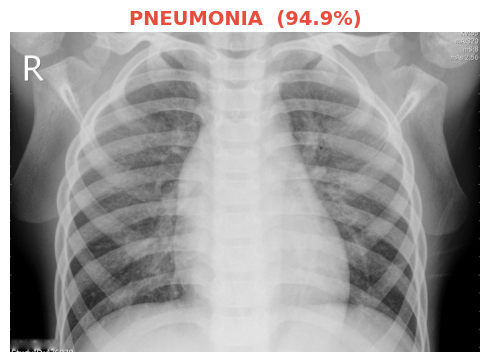

NORMAL    : 5.07%
PNEUMONIA : 94.93%


('PNEUMONIA', 0.9493005275726318)

In [19]:
def predict_single(path, model):
    model.eval()
    img = Image.open(path).convert('L')  # Grayscale
    t   = tfms['test'](img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        out  = model(t)
        prob = F.softmax(out, dim=1)[0]
        pi   = prob.argmax().item()
    plt.figure(figsize=(5, 5))
    plt.imshow(img, cmap='gray'); plt.axis('off')
    col = '#e74c3c' if pi == 1 else '#2ecc71'
    plt.title(f'{CLASSES[pi]}  ({prob[pi]*100:.1f}%)',
              color=col, fontsize=14, fontweight='bold')
    plt.tight_layout(); plt.show()
    print(f'NORMAL    : {prob[0]*100:.2f}%')
    print(f'PNEUMONIA : {prob[1]*100:.2f}%')
    return CLASSES[pi], prob[pi].item()

sample = os.path.join(DATA_DIR,'test','PNEUMONIA',
         os.listdir(os.path.join(DATA_DIR,'test','PNEUMONIA'))[0])
predict_single(sample, model)

In [20]:
# Save best weights (state dict only — always works)
torch.save(model.state_dict(), MODEL_PATH)
print('Best weights saved to:', MODEL_PATH)
print('Size: %.1f MB' % (os.path.getsize(MODEL_PATH) / 1e6))


Best weights saved to: /kaggle/working/best_pneumofusion_model.pth
Size: 100.7 MB
